In [72]:
import os
import shutil

# Project path
project_path = r"D:\Project ALl\netflix_title_project"

# Subfolders
folders = [
    "data/raw",
    "data/extracted",
    "data/processed",
    "extract",
    "load",
    "analysis"
]

# Create folders
for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

# Source folder jahan files abhi hain
source_folder = r"C:\Users\YourUsername\Downloads"  # update karo apne downloads ya jahan files hain

# File transfer
for file in os.listdir(source_folder):
    src_path = os.path.join(source_folder, file)

    # ZIP files
    if file.lower().endswith(".zip"):
        shutil.move(src_path, os.path.join(project_path, "data/raw", file))

    # CSV files
    elif file.lower().endswith(".csv"):
        if "cleaned" in file.lower():
            shutil.move(src_path, os.path.join(project_path, "data/processed", file))
        else:
            shutil.move(src_path, os.path.join(project_path, "data/extracted", file))

    # Python scripts
    elif file.lower().endswith(".py"):
        if "extract" in file.lower():
            shutil.move(src_path, os.path.join(project_path, "extract", file))
        elif "load" in file.lower():
            shutil.move(src_path, os.path.join(project_path, "load", file))

    # Jupyter notebooks
    elif file.lower().endswith(".ipynb"):
        shutil.move(src_path, os.path.join(project_path, "analysis", file))

print("Files successfully transferred to project folders")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\YourUsername\\Downloads'

In [61]:
import zipfile

zip_path = os.path.join(project_path, "data", "raw", "archive (1).zip")
extract_path = os.path.join(project_path, "data", "extracted")
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file successfully extracted to:", extract_path)

ZIP file successfully extracted to: D:\Project ALl\netflix_title_project\data\extracted


In [62]:
import pandas as pd

# Detect CSV in extracted folder
csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]
csv_path = os.path.join(extract_path, csv_files[0])

# Load CSV
df = pd.read_csv(csv_path)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [63]:
import pandas as pd
import os

project_path = r"D:\Project ALl\netflix_title_project"
extract_path = os.path.join(project_path, "data", "extracted")

# Detect CSV file in extracted folder
csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]
csv_path = os.path.join(extract_path, csv_files[0])

# Load CSV into Pandas
df = pd.read_csv(csv_path)

# Show first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [64]:
import pandas as pd
import sqlalchemy as sal

# Connection string
server = "DESKTOP-CJ2TM4F"  # Tumhara machine name
database = "master"          # Database name (ya apna custom database)
driver = "ODBC Driver 17 for SQL Server"

engine = sal.create_engine(f"mssql+pyodbc://@{server}/{database}?driver={driver}")

# Connect and load DataFrame to SQL Server
with engine.connect() as conn:
    df.to_sql("Netflix_Raw", con=conn, index=False, if_exists="replace")
    print("Data loaded to SQL Server successfully")

Data loaded to SQL Server successfully


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")  # Seaborn style applied

In [66]:
!pip install seaborn

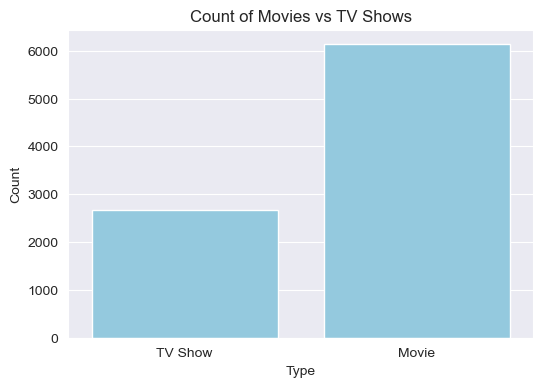

In [67]:
query = "SELECT type, COUNT(*) AS total FROM Netflix_Raw GROUP BY type;"
df_type = pd.read_sql(query, engine)

plt.figure(figsize=(6,4))
sns.barplot(x='type', y='total', data=df_type, color='skyblue')  
plt.title("Count of Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

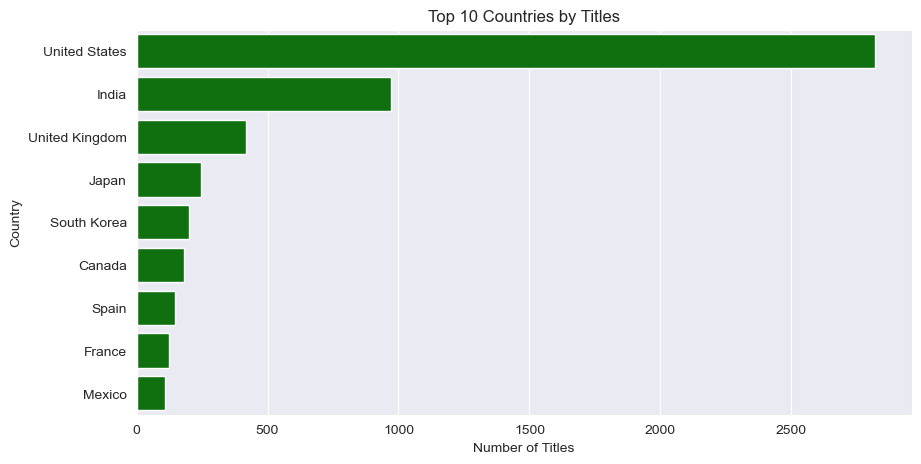

In [68]:
plt.figure(figsize=(10,5))
sns.barplot(x='total', y='country', data=df_country, color='green')
plt.title("Top 10 Countries by Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

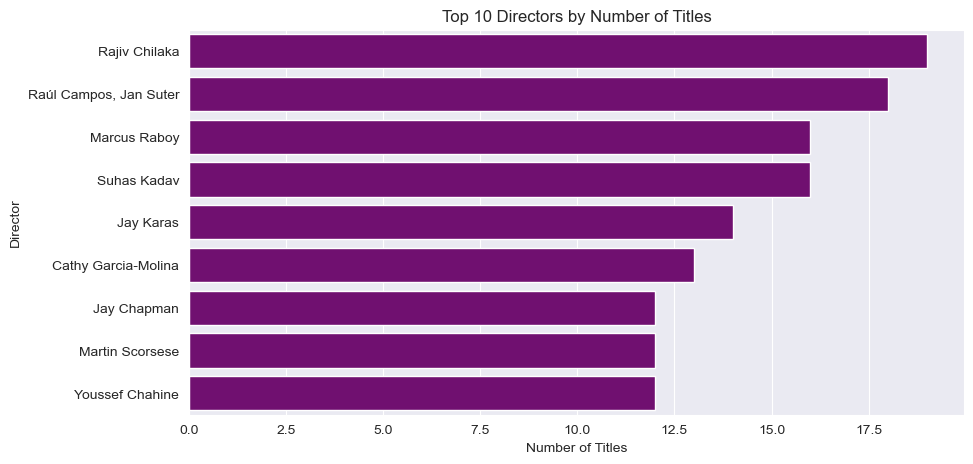

In [69]:
plt.figure(figsize=(10,5))
sns.barplot(x='total', y='director', data=df_director, color='purple')  # palette ko color se replace kiya
plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

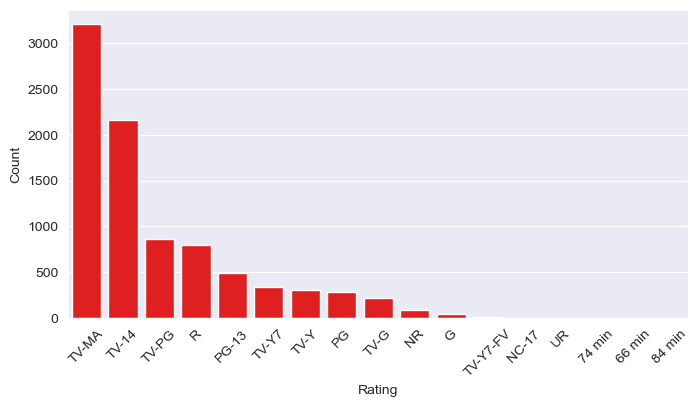

In [70]:
plt.figure(figsize=(8,4))
sns.barplot(x='rating', y='total', data=df_rating, color='red') 
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


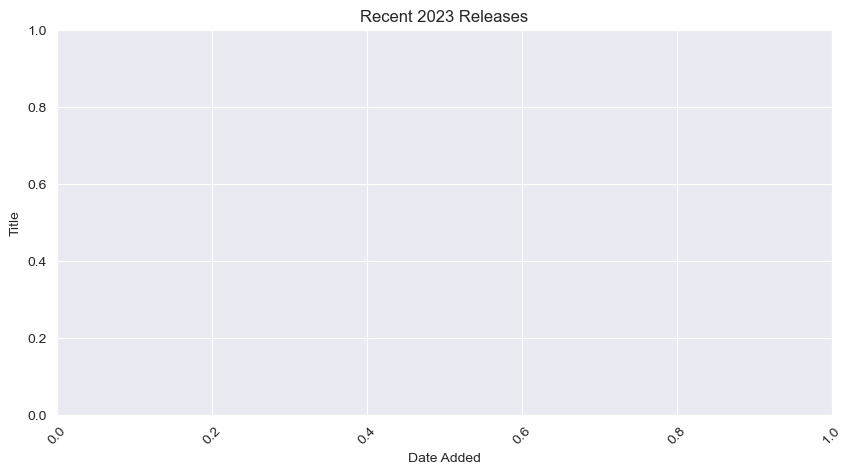

In [71]:
query = """
SELECT TOP 10 title, date_added
FROM Netflix_Raw
WHERE YEAR(date_added) = 2023
ORDER BY date_added DESC;
"""
df_recent = pd.read_sql(query, engine)

plt.figure(figsize=(10,5))
sns.barplot(x=pd.to_datetime(df_recent['date_added']).dt.date, y=df_recent['title'], data=df_recent, palette='coolwarm')
plt.title("Recent 2023 Releases")
plt.xlabel("Date Added")
plt.ylabel("Title")
plt.xticks(rotation=45)
plt.show()